In [192]:
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt



SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [193]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(data_id=42165, as_frame=True, return_X_y=True)
# Select only a subset of features of X to make the example faster to run
categorical_columns_subset = [
    "BldgType",
    "GarageFinish",
    "LotConfig",
    "Functional",
    "MasVnrType",
    "HouseStyle",
    "FireplaceQu",
    "ExterCond",
    "ExterQual",
    "PoolQC",
]

numerical_columns_subset = [
    "3SsnPorch",
    "Fireplaces",
    "BsmtHalfBath",
    "HalfBath",
    "GarageCars",
    "TotRmsAbvGrd",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "GrLivArea",
    "ScreenPorch",
]

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:", len(categorical_columns))
print("Numerical features:", len(numerical_columns))

Categorical features: 43
Numerical features: 37


/tmp/ipykernel_311003/1148551721.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [194]:
X.head(4)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml


In [195]:
print(X.isnull().sum())
print(X.info())


Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 80, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-nul

In [196]:
categorical_columns = df.select_dtypes(include="category").columns.tolist()

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    dtype=np.float32,
)

# Fill any remaining missing numeric values before converting to PyTorch tensors.
X = X.fillna(X.median(numeric_only=True))

print(f"One-hot encoded feature count: {X.shape[1]}")
print(f"Non-numeric columns: {X.select_dtypes(exclude='number').columns.tolist()}")

One-hot encoded feature count: 80
Non-numeric columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [197]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
)
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        ),
    ),
])



preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])



X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [198]:
y_train_log = np.log1p(y_train.to_numpy())
y_val_log = np.log1p(y_val.to_numpy())
y_test_log = np.log1p(y_test.to_numpy())

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32,
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32,
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32,
)




y_train_tensor = torch.tensor(
    y_train_log,
    dtype=torch.float32,
).view(-1, 1)

y_val_tensor = torch.tensor(
    y_val_log,
    dtype=torch.float32,
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test_log,
    dtype=torch.float32,
).view(-1, 1)

In [199]:
batch_size = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor,
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [200]:
class HousePriceModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

In [201]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)




input_dim = X_train_tensor.shape[1]

model = HousePriceModel(input_dim).to(device)

print("Input dimension:", input_dim)

Device: cpu
Input dimension: 37


In [202]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=500,
    lr=1e-3,
    weight_decay=1e-4,
    patience=30,
):
    loss_fn = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=10,
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_state = None

    epochs_without_improvement = 0

    for epoch in range(epochs):

        # =========================
        # Training
        # =========================

        model.train()

        running_train_loss = 0.0

        for batch_x, batch_y in train_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            predictions = model(batch_x)

            loss = loss_fn(
                predictions,
                batch_y,
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            running_train_loss += (
                loss.item() * batch_x.size(0)
            )

        epoch_train_loss = (
            running_train_loss
            / len(train_loader.dataset)
        )

        # =========================
        # Validation
        # =========================

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for batch_x, batch_y in val_loader:

                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                predictions = model(batch_x)

                loss = loss_fn(
                    predictions,
                    batch_y,
                )

                running_val_loss += (
                    loss.item() * batch_x.size(0)
                )

        epoch_val_loss = (
            running_val_loss
            / len(val_loader.dataset)
        )

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        # =========================
        # Scheduler
        # =========================

        scheduler.step(epoch_val_loss)

        # =========================
        # Early stopping
        # =========================

        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if (epoch + 1) % 10 == 0:

            current_lr = optimizer.param_groups[0]["lr"]

            print(
                f"Epoch [{epoch + 1}/{epochs}] "
                f"Train Loss: {epoch_train_loss:.5f} "
                f"Val Loss: {epoch_val_loss:.5f} "
                f"LR: {current_lr:.6f}"
            )

        if epochs_without_improvement >= patience:

            print(
                f"Early stopping at epoch {epoch + 1}"
            )

            break

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses

In [203]:
model, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=500,
    lr=1e-3,
    weight_decay=1e-4,
    patience=30,
)

Epoch [10/500] Train Loss: 1.08462 Val Loss: 4.91303 LR: 0.001000
Epoch [20/500] Train Loss: 0.40396 Val Loss: 3.59218 LR: 0.001000
Epoch [30/500] Train Loss: 0.18551 Val Loss: 2.74756 LR: 0.001000
Epoch [40/500] Train Loss: 0.09775 Val Loss: 2.08637 LR: 0.001000
Epoch [50/500] Train Loss: 0.04378 Val Loss: 1.90099 LR: 0.001000
Epoch [60/500] Train Loss: 0.03122 Val Loss: 1.77868 LR: 0.001000
Epoch [70/500] Train Loss: 0.02196 Val Loss: 1.91491 LR: 0.001000
Epoch [80/500] Train Loss: 0.02488 Val Loss: 1.64577 LR: 0.001000
Epoch [90/500] Train Loss: 0.01273 Val Loss: 1.62730 LR: 0.000500
Epoch [100/500] Train Loss: 0.00600 Val Loss: 1.61012 LR: 0.000500
Early stopping at epoch 109


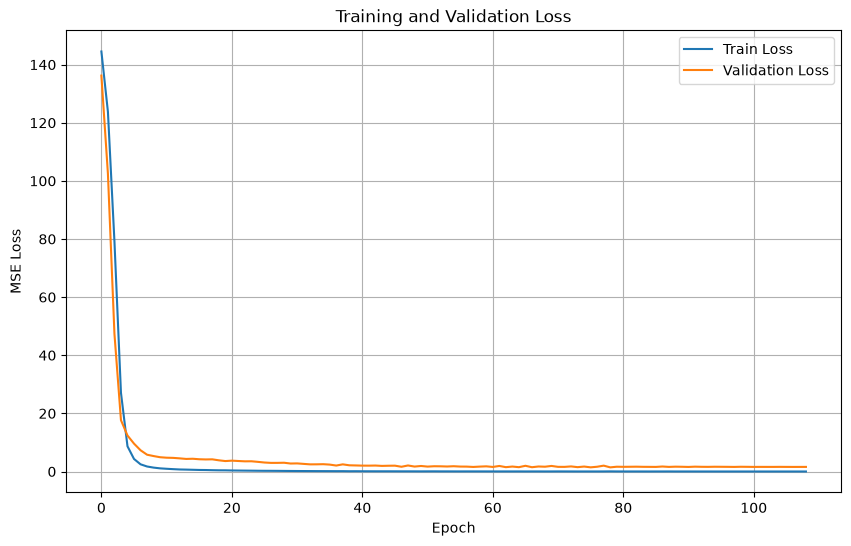

In [204]:

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Train Loss",
)

plt.plot(
    val_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()